# 02 — Exploratory Data Analysis
**Input:** india_vix_clean.csv
**Output:** 5 charts saved to reports/charts/
**Run 01_data_cleaning.ipynb first.**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)

# Load raw data — update path to where your CSV is
df = pd.read_csv("INDIAVIX_.csv",
                 usecols=["date", "open", "high", "low", "close", "previous"])

df.columns = ["trade_date", "open_price", "high_price", 
              "low_price", "close_price", "prev_close"]

df["trade_date"] = pd.to_datetime(df["trade_date"], format="%d-%m-%Y")

# Drop bad rows where OHLC = 0
df = df[(df["open_price"] > 0) & (df["high_price"] > 0) & (df["low_price"] > 0)]

df = df.sort_values("trade_date").reset_index(drop=True)

print(f"✅ Rows loaded: {len(df)}")
print(f"📅 Date range: {df['trade_date'].min().date()} → {df['trade_date'].max().date()}")
df.head()

✅ Rows loaded: 3058
📅 Date range: 2009-03-03 → 2021-07-07


,trade_date,open_price,high_price,low_price,close_price,prev_close
0,2009-03-03,43.17,43.90,41.20,43.89,43.17
1,2009-03-04,43.89,43.89,42.16,42.52,43.89
2,2009-03-05,42.52,42.71,40.41,41.49,42.52
3,2009-03-06,41.49,41.49,37.57,38.16,41.49
4,2009-03-09,38.16,41.14,38.16,40.87,38.16


In [3]:
# Correctly computed columns
df["daily_return"]    = ((df["close_price"] - df["prev_close"]) / df["prev_close"] * 100).round(4)
df["intraday_range"]  = (df["high_price"] - df["low_price"]).round(4)
df["rolling_30"]      = df["close_price"].rolling(30).mean()
df["year"]            = df["trade_date"].dt.year
df["month"]           = df["trade_date"].dt.month
df["month_name"]      = df["trade_date"].dt.strftime("%b")

# VIX fear zones
def vix_zone(v):
    if v < 15:    return "Calm"
    elif v < 25:  return "Moderate"
    elif v < 40:  return "High Fear"
    else:         return "Panic"

df["zone"] = df["close_price"].apply(vix_zone)

print("✅ Features engineered")
print(df[["trade_date","close_price","daily_return","intraday_range","zone"]].head(10))


✅ Features engineered
  trade_date  close_price  daily_return  intraday_range       zone
0 2009-03-03        43.89        1.6678            2.70      Panic
1 2009-03-04        42.52       -3.1214            1.73      Panic
2 2009-03-05        41.49       -2.4224            2.30      Panic
3 2009-03-06        38.16       -8.0260            3.92  High Fear
4 2009-03-09        40.87        7.1017            2.98      Panic
5 2009-03-12        39.27       -3.9149            2.37  High Fear
6 2009-03-13        35.56       -9.4474            4.19  High Fear
7 2009-03-16        36.70        3.2058            2.32  High Fear
8 2009-03-17        38.43        4.7139            3.91  High Fear
9 2009-03-18        38.15       -0.7286            1.87  High Fear


In [4]:
df.to_csv("india_vix_clean.csv", index=False)
print("✅ Cleaned CSV saved — open this in Excel for your data layer")

✅ Cleaned CSV saved — open this in Excel for your data layer


 Chart 1: Full VIX History with Fear Zones

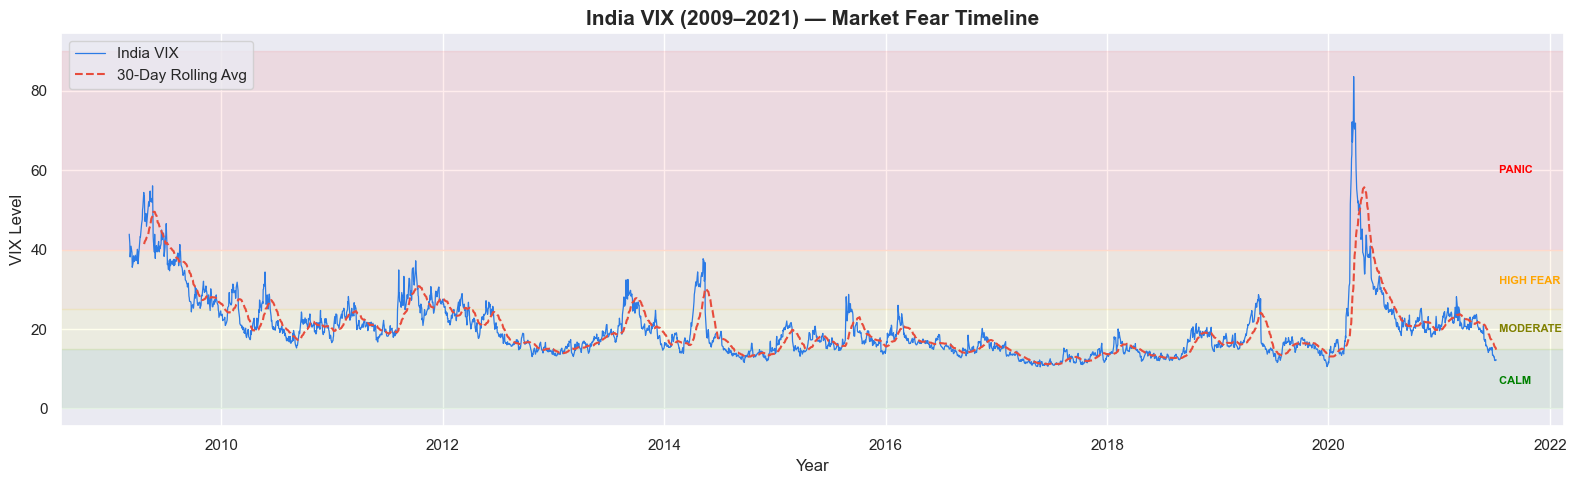

💾 Saved: chart01_vix_history.png


In [5]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df["trade_date"], df["close_price"], color="#2c7be5", linewidth=0.9, label="India VIX")
ax.plot(df["trade_date"], df["rolling_30"],  color="#e74c3c", linewidth=1.5, 
        linestyle="--", label="30-Day Rolling Avg")

ax.axhspan(0,  15, alpha=0.07, color="green")
ax.axhspan(15, 25, alpha=0.07, color="yellow")
ax.axhspan(25, 40, alpha=0.07, color="orange")
ax.axhspan(40, 90, alpha=0.07, color="red")

# Label zones on right side
for level, label, color in zip([7, 20, 32, 60], 
                                 ["CALM", "MODERATE", "HIGH FEAR", "PANIC"],
                                 ["green","olive","orange","red"]):
    ax.text(df["trade_date"].max(), level, f" {label}", 
            color=color, fontsize=8, va="center", fontweight="bold")

ax.set_title("India VIX (2009–2021) — Market Fear Timeline", fontsize=15, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("VIX Level")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("chart01_vix_history.png", dpi=150)
plt.show()
print("💾 Saved: chart01_vix_history.png")

Chart 2: Monthly Seasonality Heatmap

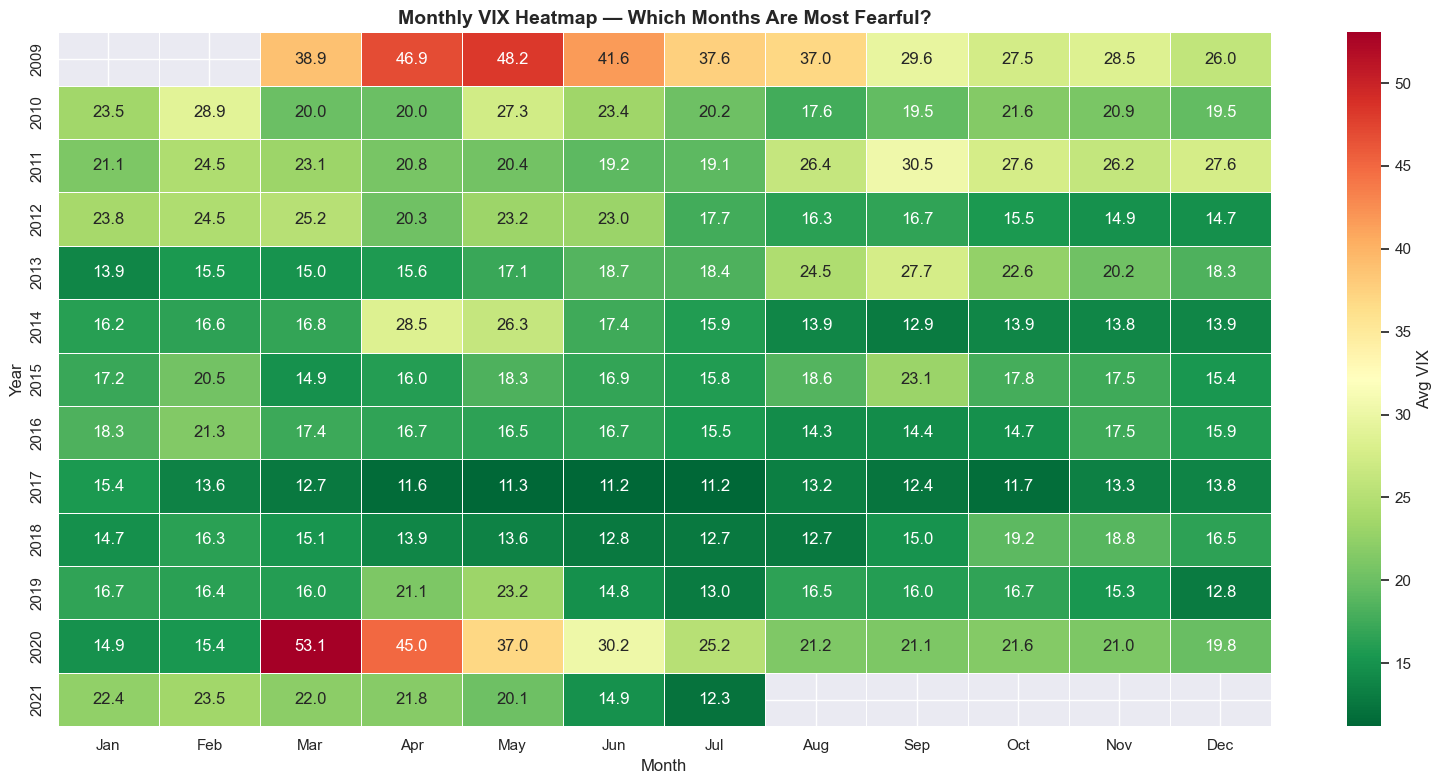

💾 Saved: chart02_monthly_heatmap.png


In [6]:
pivot = df.pivot_table(values="close_price", index="year", columns="month", aggfunc="mean")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot, cmap="RdYlGn_r", annot=True, fmt=".1f",
            linewidths=0.4, cbar_kws={"label": "Avg VIX"}, ax=ax)
ax.set_title("Monthly VIX Heatmap — Which Months Are Most Fearful?", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.savefig("chart02_monthly_heatmap.png", dpi=150)
plt.show()
print("💾 Saved: chart02_monthly_heatmap.png")

Chart 3: Yearly Average VIX Bar Chart

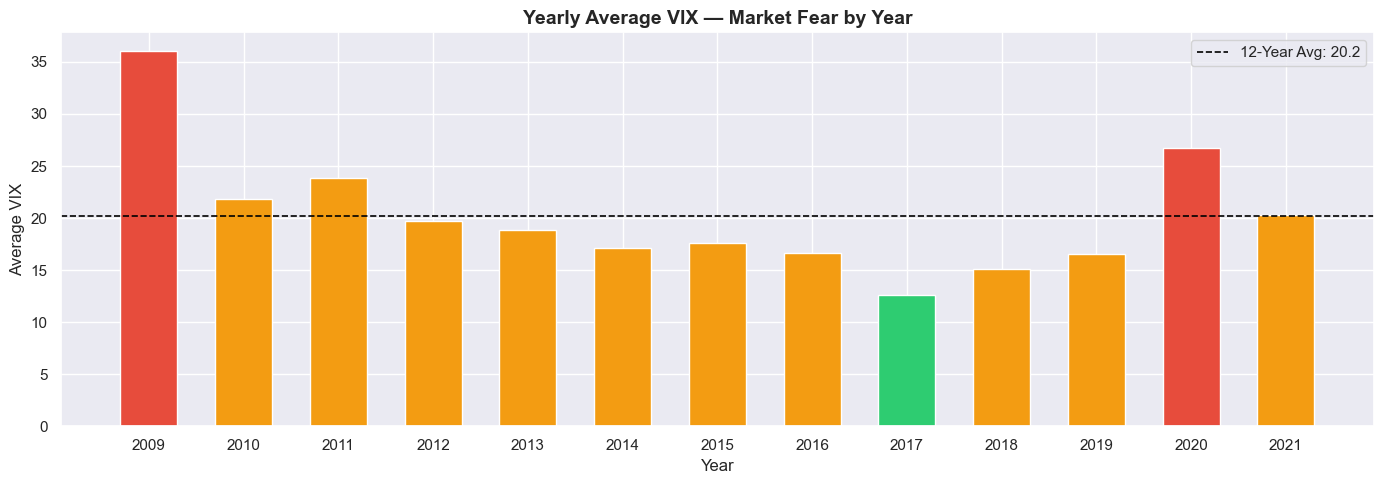

💾 Saved: chart03_yearly_avg.png


In [12]:
yearly = df.groupby("year")["close_price"].mean().reset_index()
colors = ["#e74c3c" if v > 25 else "#f39c12" if v > 15 else "#2ecc71" 
          for v in yearly["close_price"]]
overall_avg = yearly["close_price"].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(yearly["year"], yearly["close_price"], color=colors, edgecolor="white", width=0.6)
ax.axhline(overall_avg, color="black", linestyle="--", linewidth=1.2,
           label=f"12-Year Avg: {overall_avg:.1f}")
ax.set_title("Yearly Average VIX — Market Fear by Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Average VIX")
ax.set_xticks(yearly["year"])
ax.legend()
plt.tight_layout()
plt.savefig("chart03_yearly_avg.png", dpi=150)
plt.show()
print("💾 Saved: chart03_yearly_avg.png")

Chart 4: Daily Return Distribution

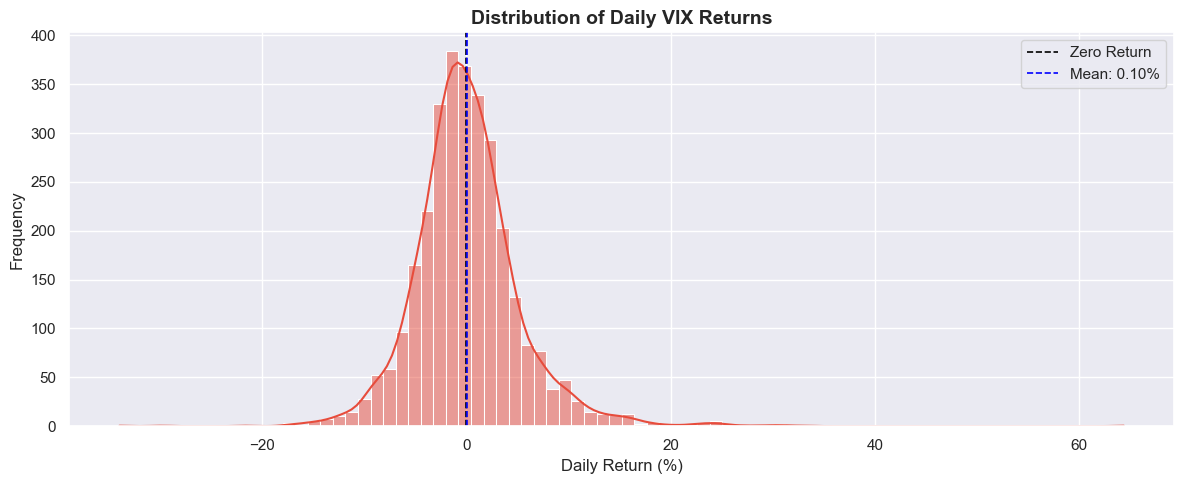

💾 Saved: chart04_return_dist.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(df["daily_return"], bins=80, kde=True, color="#e74c3c", ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1.2, label="Zero Return")
ax.axvline(df["daily_return"].mean(), color="blue", linestyle="--", linewidth=1.2,
           label=f"Mean: {df['daily_return'].mean():.2f}%")
ax.set_title("Distribution of Daily VIX Returns", fontsize=14, fontweight="bold")
ax.set_xlabel("Daily Return (%)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig("chart04_return_dist.png", dpi=150)
plt.show()
print("💾 Saved: chart04_return_dist.png")

 Chart 5: Intraday Range Over Time

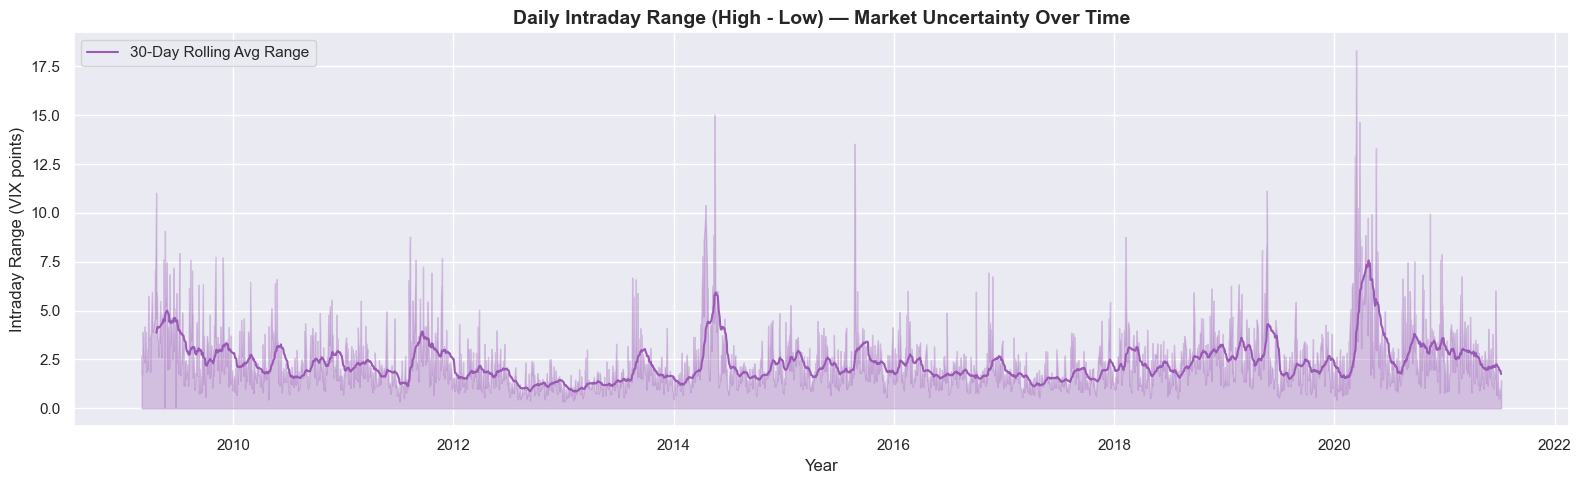

💾 Saved: chart05_intraday_range.png


In [9]:
df["rolling_range"] = df["intraday_range"].rolling(30).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(df["trade_date"], df["intraday_range"], alpha=0.3, color="#9b59b6")
ax.plot(df["trade_date"], df["rolling_range"], color="#9b59b6", linewidth=1.5,
        label="30-Day Rolling Avg Range")
ax.set_title("Daily Intraday Range (High - Low) — Market Uncertainty Over Time",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Intraday Range (VIX points)")
ax.legend()
plt.tight_layout()
plt.savefig("chart05_intraday_range.png", dpi=150)
plt.show()
print("💾 Saved: chart05_intraday_range.png")

Summary Stats 

In [10]:
print("=" * 50)
print("        INDIA VIX — KEY STATISTICS")
print("=" * 50)
print(f"Period          : {df['trade_date'].min().date()} to {df['trade_date'].max().date()}")
print(f"Trading Days    : {len(df)}")
print(f"Average VIX     : {df['close_price'].mean():.2f}")
print(f"Highest VIX     : {df['close_price'].max():.2f} on {df.loc[df['close_price'].idxmax(),'trade_date'].date()}")
print(f"Lowest VIX      : {df['close_price'].min():.2f} on {df.loc[df['close_price'].idxmin(),'trade_date'].date()}")
print(f"Calm days (<15) : {(df['zone']=='Calm').sum()}")
print(f"Panic days (>40): {(df['zone']=='Panic').sum()}")
print(f"Avg Daily Return: {df['daily_return'].mean():.4f}%")
print("=" * 50)

        INDIA VIX — KEY STATISTICS
Period          : 2009-03-03 to 2021-07-07
Trading Days    : 3058
Average VIX     : 20.01
Highest VIX     : 83.61 on 2020-03-24
Lowest VIX      : 10.45 on 2017-05-25
Calm days (<15) : 769
Panic days (>40): 89
Avg Daily Return: 0.0970%
